<a href="https://colab.research.google.com/github/AliaF123/Laptop_Review/blob/main/laptop_review_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import re
import nltk
import warnings

from wordcloud import WordCloud

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from nltk.sentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Laptop_Review/final.csv")

In [ ]:
#preview data
df.head(10)

In [19]:
df['product_name']

,product_name
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
...,...
25933,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25934,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25935,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25936,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...


In [20]:
print("Rows, Columns:", df.shape)

Rows, Columns: (25938, 8)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25938 entries, 0 to 25937
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    25938 non-null  object 
 1   overall_rating  25938 non-null  float64
 2   no_ratings      25938 non-null  object 
 3   no_reviews      25938 non-null  object 
 4   rating          25938 non-null  int64  
 5   title           25938 non-null  object 
 6   review          25938 non-null  object 
 7   final_review    24113 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 1.6+ MB


In [22]:
df.isnull().sum()

,0
product_name,0
overall_rating,0
no_ratings,0
no_reviews,0
rating,0
title,0
review,0
final_review,1825


In [23]:
df.duplicated().sum()

np.int64(7122)

In [24]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [25]:
def clean_review(text):

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [26]:
df['clean_review'] = df['review'].apply(clean_review)

In [27]:
df['clean_review']

,clean_review
0,loved first macbook earned hardwork
1,battery lasted longer first relationship day l...
2,great deal happy performance battery lifeorigi...
3,awesome build quality good display battery cam...
4,ordered came know seller reviewi scared condit...
...,...
25933,great balance speed portability reliability ev...
25934,build quality feel premium laptop handle multi...
25935,great balance speed portability reliability ev...
25936,laptop performs well task although battery cou...


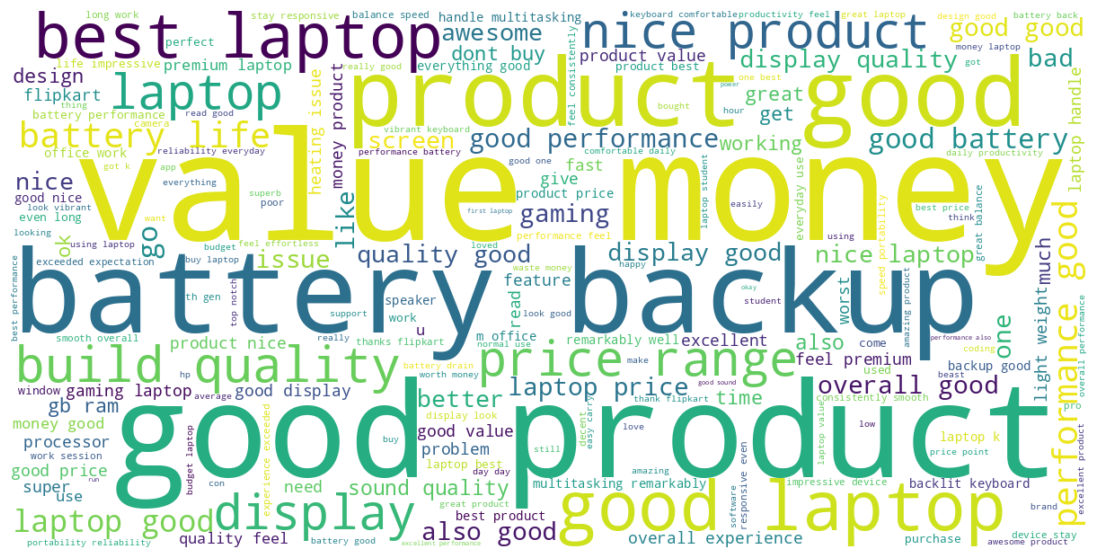

In [28]:

# Select the column that has reviews
text_column = "clean_review"

# Combine all reviews into one big text
text = " ".join(df[text_column].dropna().astype(str))

# Create word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords={"the","is","and","a","to","it","this","was","for"}
).generate(text)

# Show result
plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [29]:
# Aspect Dictionary
aspect_dict = {

    "performance":[
        "performance",
        "speed",
        "fast",
        "slow",
        "lag",
        "processor",
        "cpu",
        "multitasking"
    ],

    "battery":[
        "battery",
        "charging",
        "charge",
        "backup",
        "power"
    ],

    "display":[
        "display",
        "screen",
        "brightness",
        "resolution",
        "color"
    ],

    "keyboard":[
        "keyboard",
        "typing",
        "trackpad",
        "touchpad"
    ],

    "heating":[
        "heat",
        "heating",
        "thermal",
        "temperature"
    ],

    "price":[
        "price",
        "cost",
        "expensive",
        "cheap",
        "value"
    ],

    "build":[
        "build",
        "design",
        "quality",
        "durable"
    ],

    "portability":[
        "weight",
        "portable",
        "lightweight"
    ]
}

In [30]:
#Keyword Aspect Extraction
def extract_keyword_aspects(text):

    tokens = set(text.split())

    aspects_found = []

    for aspect, keywords in aspect_dict.items():

        if len(tokens.intersection(keywords)) > 0:
            aspects_found.append(aspect)

    return aspects_found

In [ ]:
df["keyword_aspects"] = (
    df["clean_review"]
    .apply(extract_keyword_aspects)
)

In [31]:
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["vader_sentiment"] = (
    df["clean_review"]
    .apply(vader_sentiment)
)

df[["review","vader_sentiment"]].head(10)

,review,vader_sentiment
0,"Loved it, it's my first MacBook that I earned ...",Positive
1,Battery lasted longer than my first relationsh...,Positive
2,Such a great deal.. very happy with the perfor...,Positive
3,"Awesome build quality and very good display, b...",Positive
4,When i ordered and came to know about seller r...,Positive
5,Super product,Positive
6,Go for it..its awesome,Positive
7,"Best , best and best 🫶🏻👑🍎",Positive
8,Its really very good and compact device.,Positive
9,"Superb built quality, Amazing performance and ...",Positive


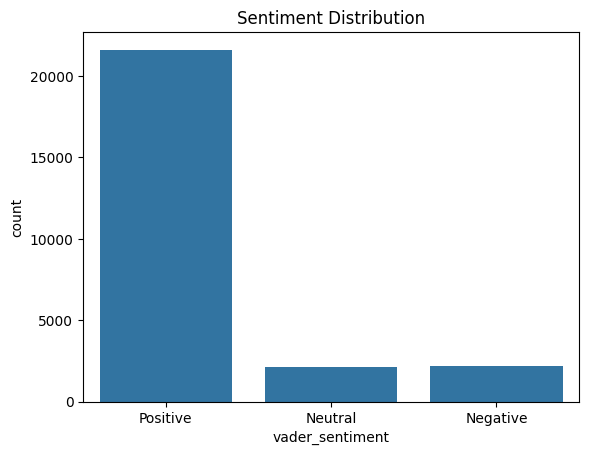

In [32]:
sns.countplot(
    x="vader_sentiment",
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

In [33]:
!pip install transformers torch -q

In [34]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [35]:
sentiment_pipeline(
    "The laptop performance is amazing"
)

[{'label': 'POSITIVE', 'score': 0.9998608827590942}]

In [ ]:
reviews = df["clean_review"].fillna("").astype(str).tolist()

results = sentiment_pipeline(
    reviews,
    batch_size=32,
    truncation=True
)

df["bert_sentiment"] = [r["label"] for r in results]
df["bert_score"] = [r["score"] for r in results]

In [ ]:
df[["clean_review", "bert_sentiment", "bert_score"]].head()

In [ ]:
df["bert_sentiment"] = df["bert_sentiment"].str.upper()

In [ ]:
df["bert_sentiment"].value_counts()

In [ ]:
aspect_sentiment = df[["keyword_aspects", "bert_sentiment"]].explode("keyword_aspects")

In [ ]:
aspect_sentiment = aspect_sentiment.dropna()

In [ ]:
aspect_sentiment.head(10)

In [ ]:
aspect_summary = pd.crosstab(
    aspect_sentiment["keyword_aspects"],
    aspect_sentiment["bert_sentiment"]
)

aspect_summary

In [ ]:
aspect_summary.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Aspect-wise Sentiment (BERT)")
plt.ylabel("Count")
plt.show()

In [ ]:
positive_aspects = (
    aspect_sentiment[
        aspect_sentiment["bert_sentiment"] == "POSITIVE"
    ]["keyword_aspects"]
    .value_counts()
)

positive_aspects

In [ ]:
negative_aspects = (
    aspect_sentiment[
        aspect_sentiment["bert_sentiment"] == "NEGATIVE"
    ]["keyword_aspects"]
    .value_counts()
)

negative_aspects

In [ ]:
aspect_percent = aspect_summary.div(
    aspect_summary.sum(axis=1),
    axis=0
) * 100

aspect_percent.round(2)

In [ ]:
aspect_percent.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Aspect-wise Sentiment (%)")
plt.ylabel("Percentage")
plt.show()